# Solution to Exercise Set 4 - 1  Implementation of a Transformer

In this notebook you will learn how to implement the **transformer encoder**, train it and plot attention maps. You will also get an intuition of why the positional encoding is important.

Transformers are the basic building block of popular models like GPT-3 and DeepSeek and also play a role in other tasks like text-to-image.

The transformer implementation here is based on https://www.tensorflow.org/text/tutorials/transformer.

We'll use an artificial dataset and a very small sized transformer to make this notebook run on any hardware.

YOUR TASK: 
1. Read carefully and execute the notebook and understand what's going on. 
2. Do the task at the end of the notebook.
3. Change the flag `use_positional_encoding` to `False` an rerun training. Observe how the results change.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

## 1) Implementing the transformer encoder

![alt text](../../../transformer/encoder.png "The original transformer architecture")

### 1.1) Positional Encoding and Embedding
We want to understand what it does.
In short, it generates a matrix, where the size of the first dimension is the sequence length and the size of the second is a user defined depth. The positional embedding has these useful properties:

- It is a continuous representation that can just be added to our regular token embeddings.
- Absolute positions are always encoded the same way across all input sequences.
- The encoding of two positions differ the more these positions are away from each other.

Shape of the positional encoding: torch.Size([2048, 512])


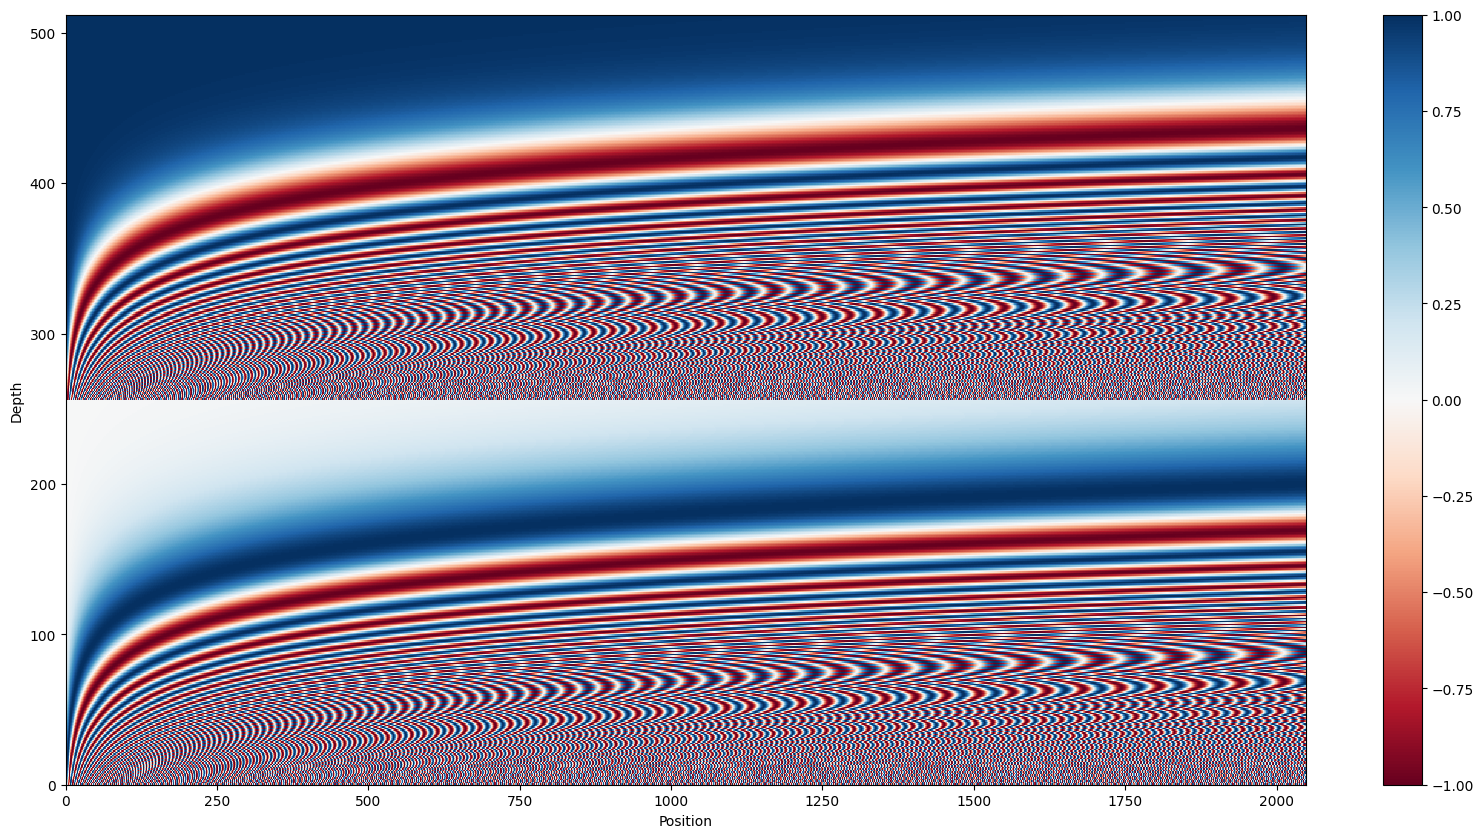

In [2]:
def positional_encoding(length, depth):
    depth_half = depth / 2
    positions = np.arange(length)[:, np.newaxis]   # (seq, 1)
    depths = np.arange(depth_half)[np.newaxis, :] / depth_half  # (1, depth_half)
    angle_rates = 1 / (10000**depths)  # (1, depth_half)
    angle_rads = positions * angle_rates  # (seq, depth_half)
    pos_encoding = np.concatenate([np.sin(angle_rads), np.cos(angle_rads)], axis=-1)
    return torch.tensor(pos_encoding, dtype=torch.float32)

pos_encoding = positional_encoding(length=2048, depth=512)
print("Shape of the positional encoding:", pos_encoding.shape)

# Compute a positional encoding up to a maximum length.
# Usually, we set the length to a value beyond any reasonable input sequence length.
# We will not be able to use the model on sequences longer than this value.
# We also state a depth, which is the number of channels/dimensions each position is encoded with.
# We set this to be the same depth that the embeddings in our model have.
plt.figure(figsize=(20, 10))
plt.pcolormesh(pos_encoding.numpy().T, cmap='RdBu')
plt.ylabel('Depth')
plt.xlabel('Position')
plt.colorbar()
plt.show()

With the positional embedding at hand, we can implement a custom layer (nn.Module) that uses [torch.nn.Embedding](https://pytorch.org/docs/stable/generated/torch.nn.Embedding.html) to get a token embedding.

You can put any functionality you like in the `call` method of your custom layer. Your layer can then later be used as a component of the model just as build-in layers like `Linear`.

The position encoding in the following is a **constant** it is not trained as part of the model.

In [3]:
class PositionalEmbedding(nn.Module):
    """
    A custom layer that maps a batch of input sequences (token indices) to embedded
    sequences. The embeddings are scaled and (optionally) added to a non-trainable 
    positional encoding.
    """
    def __init__(self, vocab_size, d_model, use_positional_encoding=True):
        super().__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.use_positional_encoding = use_positional_encoding
        if self.use_positional_encoding:
            self.pos_encoding = positional_encoding(2048, d_model)  # (2048, d_model)
            
    def forward(self, x):
        # x: (batch, seq_len)
        x = self.embedding(x).float()  # (batch, seq_len, d_model)
        x = x * torch.sqrt(torch.tensor(self.d_model, dtype=torch.float32))
        if self.use_positional_encoding:
            seq_len = x.size(1)
            # unsqueeze(0): adds batch-dim so that pos_encoding matches (batch, seq_len, d_model)
            x = x + self.pos_encoding[:seq_len, :].unsqueeze(0)
        return x

### 1.2) The basic building blocks

In [4]:
class SelfAttention(nn.Module):
    """
    Computes one self-attention step on the input sequences.
    """
    def __init__(self, num_heads, d_model, dropout=0.1):
        super().__init__()
        # PyTorch's MultiheadAttention expects input shape: (seq, batch, embed_dim)
        self.mha = nn.MultiheadAttention(embed_dim=d_model, num_heads=num_heads,
                                         dropout=dropout, batch_first=True)
        self.layernorm = nn.LayerNorm(d_model)
        
    def forward(self, x):
        # x: (batch, seq, d_model)
        # MultiheadAttention (with batch_first=True) returns attn_output: (batch, seq, d_model)
        attn_output, attn_scores = self.mha(x, x, x, need_weights=True)
        x = self.layernorm(x + attn_output)
        self.last_attn_scores = attn_scores  # save attention scores for later plotting
        return x

In [5]:
class FeedForward(nn.Module):
    """
    A standard feed forward network with dropout, skip connection and layer normalization.
    """
    def __init__(self, d_model, dff, dropout_rate=0.1):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Linear(d_model, dff),
            nn.ReLU(),
            nn.Linear(dff, d_model),
            nn.Dropout(dropout_rate)
        )
        self.layernorm = nn.LayerNorm(d_model)
        
    def forward(self, x):
        return self.layernorm(x + self.seq(x))


In [6]:
class EncoderLayer(nn.Module):
    """
    One encoder step comprising self-attention and a feed forward network.
    """
    def __init__(self, d_model, num_heads, dff, dropout_rate=0.1):
        super().__init__()
        self.self_attention = SelfAttention(num_heads=num_heads, d_model=d_model, dropout=dropout_rate)
        self.ffn = FeedForward(d_model, dff, dropout_rate)
        
    def forward(self, x):
        x = self.self_attention(x)
        x = self.ffn(x)
        return x

In [7]:
class Encoder(nn.Module):
    """
    The final encoder. It first applies token embeddings (with positional encoding)
    and then passes the embedded sequences through a stack of encoder layers.
    """
    def __init__(self, *, num_layers, d_model, num_heads, dff, vocab_size,
                 dropout_rate=0.3, use_positional_encoding=True):
        super().__init__()
        self.d_model = d_model
        self.num_layers = num_layers
        self.pos_embedding = PositionalEmbedding(vocab_size, d_model, use_positional_encoding)
        self.enc_layers = nn.ModuleList([EncoderLayer(d_model, num_heads, dff, dropout_rate) for _ in range(num_layers)])
        self.dropout = nn.Dropout(dropout_rate)
        
    def forward(self, x):
        # x: (batch, seq_len) of token ids
        x = self.pos_embedding(x)  # (batch, seq_len, d_model)
        x = self.dropout(x)
        for i in range(self.num_layers):
            x = self.enc_layers[i](x)
        return x  # (batch, seq_len, d_model)

In [8]:
class SimpleTransformerEncoder(nn.Module):
    """
    Puts it all together: first a transformer encoder block is applied (which produces a
    sequence of embeddings) and then we reduce over the sequence dimension (here, by taking
    the mean) to get a final representation that is mapped to a logit.
    """
    def __init__(self):
        super().__init__()
        d = 8
        self.encoder = Encoder(num_layers=1, d_model=d, num_heads=1, dff=16, vocab_size=26, dropout_rate=0.0, use_positional_encoding=True)
        self.final_layer = nn.Linear(d, 1)
        
    def forward(self, x):
        # x: (batch, seq_len) of token ids
        emb = self.encoder(x)                 # (batch, seq_len, d_model)
        emb_sums = emb.mean(dim=1)            # (batch, d_model), use mean reduction over emb_sums 
        # alternatively, one can also use the final hidden state
        # emb_sums = emb[:,-1,:]
        logits = self.final_layer(emb_sums)   # (batch, 1)
        return logits

In [9]:
model = SimpleTransformerEncoder()
#print(model)
from torchinfo import summary
summary(model, input_data=torch.zeros((64,40), dtype=torch.long), depth=6)

Layer (type:depth-idx)                             Output Shape              Param #
SimpleTransformerEncoder                           [64, 1]                   --
├─Encoder: 1-1                                     [64, 40, 8]               --
│    └─PositionalEmbedding: 2-1                    [64, 40, 8]               --
│    │    └─Embedding: 3-1                         [64, 40, 8]               208
│    └─Dropout: 2-2                                [64, 40, 8]               --
│    └─ModuleList: 2-3                             --                        --
│    │    └─EncoderLayer: 3-2                      [64, 40, 8]               --
│    │    │    └─SelfAttention: 4-1                [64, 40, 8]               --
│    │    │    │    └─MultiheadAttention: 5-1      [64, 40, 8]               288
│    │    │    │    └─LayerNorm: 5-2               [64, 40, 8]               16
│    │    │    └─FeedForward: 4-2                  [64, 40, 8]               --
│    │    │    │    └─Sequential:

## 2) A toy problem to put the transformer into practice

To get a better intuition of what a positional embedding can do for us, we want to solve the following simple problem:

Given a string with variable length consisting of random upper case characters from the latin alphabet, such that A and B each occur exactly 1 time. "Predict" whether A comes before B in the sequence (output 1) or vise versa (output 0). 

We say "predict" here although for a human this task is trivial, but for a machine learning model we will see that the notion of order inside the sequence depends on the positional encoding.

Example 1:
- Sequence: IFGIE**A**HWIEIFI**B**EJQ
- Label: 1

Example 2:
- Sequence: ZSU**B**UE**A**UFH
- Label: 0

In [10]:
def make_dataset(num_seq, len_min=40, len_max=60, batch_size=64):
    # Token encoding: 0 = padding, 1 = A, 2 = B, 3-25 = other letters.
    seqs = np.random.randint(3, 26, size=(num_seq, len_max))
    lens = np.random.randint(len_min, len_max, size=num_seq)
    labels = np.zeros(num_seq)
    for i, l in enumerate(lens):
        seqs[i, l:] = 0  # padding
        # draw two positions for A and B without replacement
        pos_AB = np.random.choice(np.arange(l), size=2, replace=False)
        seqs[i, pos_AB[0]] = 1
        seqs[i, pos_AB[1]] = 2
        if pos_AB[0] < pos_AB[1]:
            labels[i] = 1
    seqs = torch.tensor(seqs, dtype=torch.long)
    labels = torch.tensor(labels, dtype=torch.float32).unsqueeze(1)
    dataset = torch.utils.data.TensorDataset(seqs, labels)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    return loader

# Test dataset creation:
train_loader = make_dataset(20000, len_min=10, len_max=15, batch_size=8)
for seqs, labels in train_loader:
    for s, l in zip(seqs, labels):
        print(f"sequence = {s} label = {l}")
    break
# Run one forward pass
print ("predictions (logits) =",  model(seqs).flatten().detach().numpy())

sequence = tensor([14, 22, 22,  9, 23, 22,  1,  9, 15,  2, 18, 10, 12, 11,  0]) label = tensor([1.])
sequence = tensor([ 6,  6, 16,  2,  1,  5, 16, 24,  8, 19,  0,  0,  0,  0,  0]) label = tensor([0.])
sequence = tensor([14,  1, 20,  4,  9, 23,  2, 15, 10,  8, 13,  0,  0,  0,  0]) label = tensor([1.])
sequence = tensor([12, 22, 15,  4, 13,  1,  2, 11, 23, 15,  0,  0,  0,  0,  0]) label = tensor([1.])
sequence = tensor([ 2, 12,  4, 15, 22, 13, 14, 15, 13,  7, 15,  1, 19,  4,  0]) label = tensor([0.])
sequence = tensor([ 1, 22, 10, 23, 11,  5, 25, 17,  2, 25,  7, 21,  0,  0,  0]) label = tensor([1.])
sequence = tensor([ 4, 19,  2, 24, 13,  1,  5, 19, 12, 23,  0,  0,  0,  0,  0]) label = tensor([0.])
sequence = tensor([18, 17,  5, 15,  8,  6,  2, 19, 13, 25, 25,  8,  1, 22,  0]) label = tensor([0.])
predictions (logits) = [-0.24158688 -0.53328735 -0.04240318  0.15158029 -0.00548187 -0.29822463
 -0.33047366 -0.37840945]


The model outputs logits, not probabilities. To get probabilities us `tf.math.sigmoid`.

In [11]:
from torchsummary import summary
#summary(model, (15,))

In [12]:
# Create training and validation DataLoaders (using our make_dataset function)
train_loader = make_dataset(100000, len_min=15, len_max=20, batch_size=512)
val_loader = make_dataset(1000, len_min=10, len_max=15, batch_size=512)

criterion = nn.BCEWithLogitsLoss()  # from_logits=True equivalent
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-3)

In [13]:
num_epochs = 10
model.train()
for epoch in range(num_epochs):
    epoch_loss = 0.0
    epoch_correct = 0
    epoch_total = 0
    for seqs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(seqs)  # (batch, 1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * seqs.size(0)
        
        # Compute predicted labels: threshold sigmoid output at 0.5.
        preds = (torch.sigmoid(outputs) >= 0.5).float()
        epoch_correct += (preds == labels).sum().item()
        epoch_total += labels.size(0)
        
    avg_loss = epoch_loss / len(train_loader.dataset)
    acc = epoch_correct / epoch_total
    print(f"Epoch {epoch+1}/{num_epochs} -- Loss: {avg_loss:.4f} -- Accuracy: {acc:.4f}")


Epoch 1/10 -- Loss: 0.6919 -- Accuracy: 0.5206
Epoch 2/10 -- Loss: 0.5818 -- Accuracy: 0.6918
Epoch 3/10 -- Loss: 0.3608 -- Accuracy: 0.8377
Epoch 4/10 -- Loss: 0.3191 -- Accuracy: 0.8579
Epoch 5/10 -- Loss: 0.3000 -- Accuracy: 0.8660
Epoch 6/10 -- Loss: 0.2793 -- Accuracy: 0.8769
Epoch 7/10 -- Loss: 0.2645 -- Accuracy: 0.8851
Epoch 8/10 -- Loss: 0.2467 -- Accuracy: 0.8946
Epoch 9/10 -- Loss: 0.2294 -- Accuracy: 0.9036
Epoch 10/10 -- Loss: 0.2093 -- Accuracy: 0.9148


In [14]:
model.eval()
val_loss = 0.0
with torch.no_grad():
    for seqs, labels in val_loader:
        outputs = model(seqs)
        loss = criterion(outputs, labels)
        val_loss += loss.item() * seqs.size(0)
avg_val_loss = val_loss / len(val_loader.dataset)
print("Validation Loss:", avg_val_loss)

Validation Loss: 0.7614879975318909


## Your task: Plot the attention maps

One advantage of attention models is that their inner workings can be visualized and to some extent interpreted by humans.

Your task is to produce such a plot.

In [15]:
# get one validation batch
for seqs, labels in val_loader:
    break
# Forward pass in evaluation mode to capture attention scores.
_ = model(seqs)

*Task*: Extract the attention scores from one attention head in one of the encoder layers in the model. Remember (check it out in the code earlier) that the `last_attn_scores` were stored as a member of the `self_attention` layer in each encoder layer. The scores will always be with respect to the last seen sequences.

Tips:
- start from 'model' and follow down the hierarchy of members and list elements all the way down to `last_attn_scores`
- the syntax to access class members is model.encoder.d_model to give an example.
- check out the shape of `last_attn_scores` and convert it to numpy (tips: .cpu(), .numpy())
- you can use `ax.matshow` to visualize a matrix

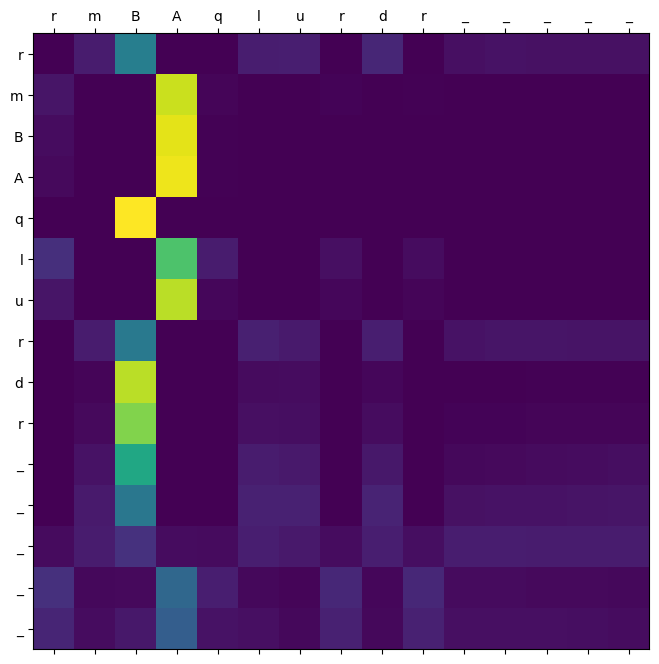

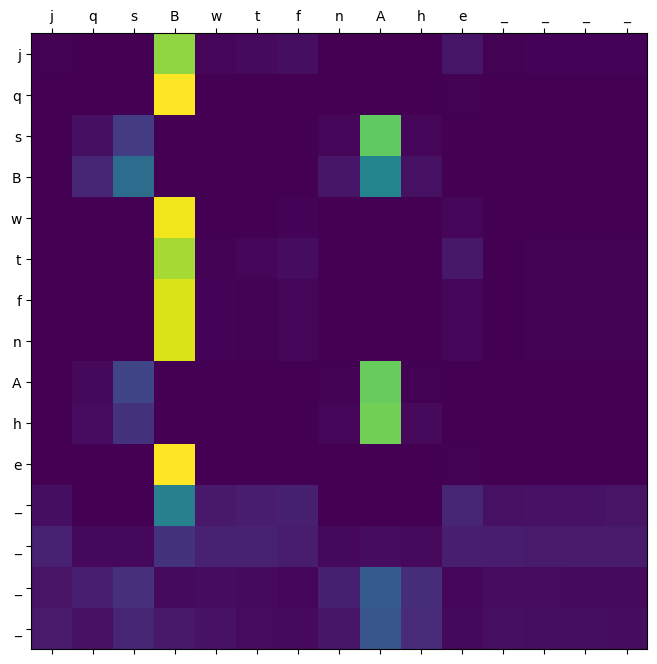

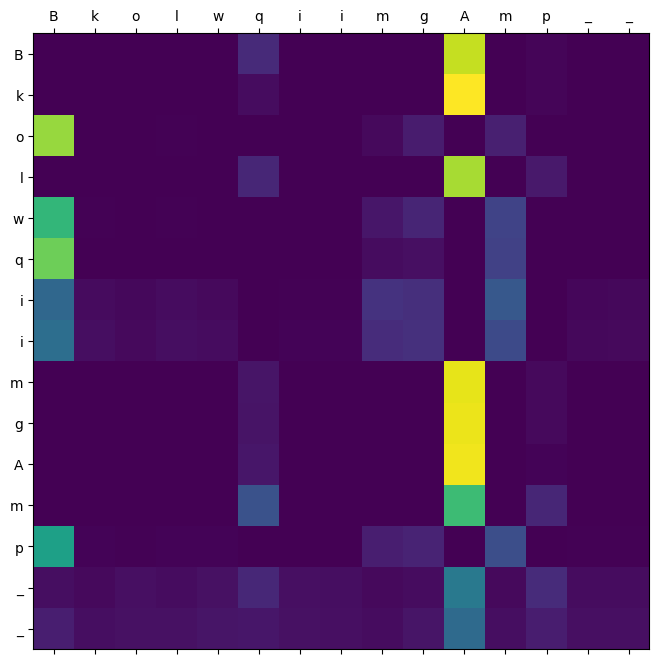

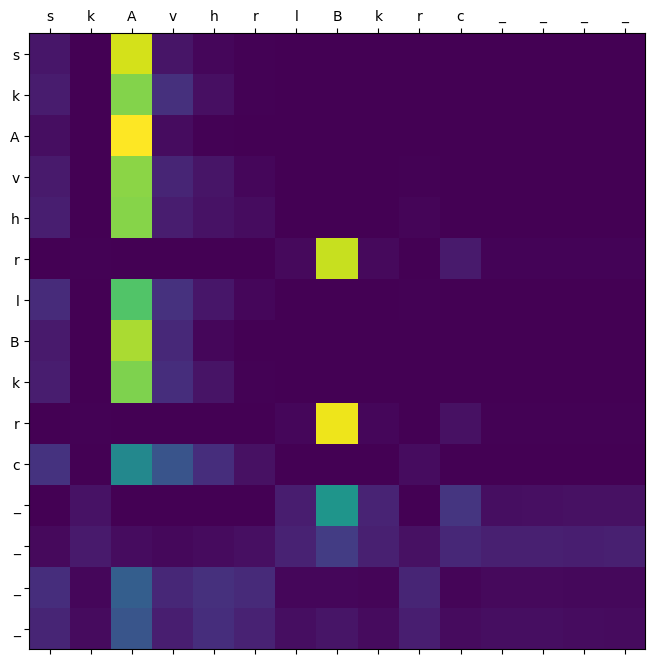

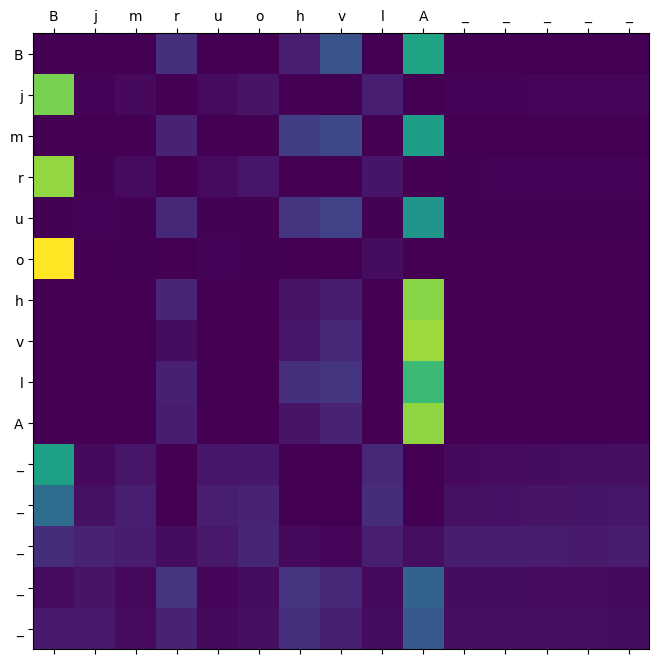

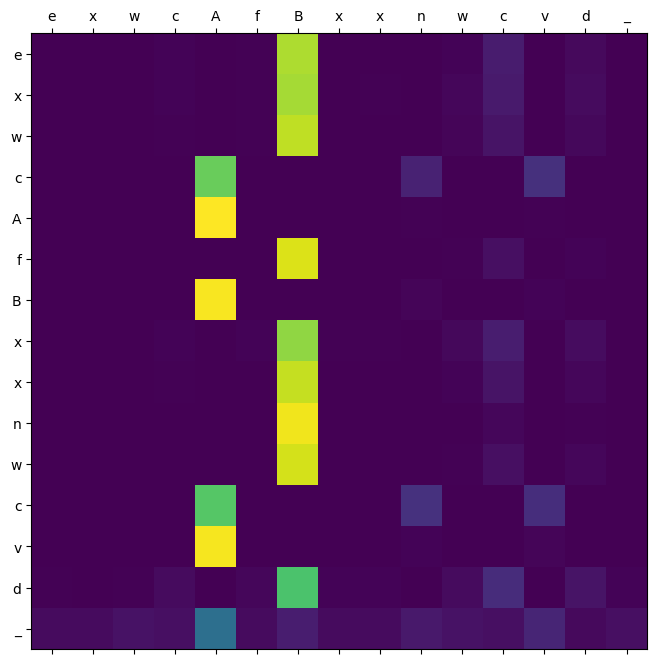

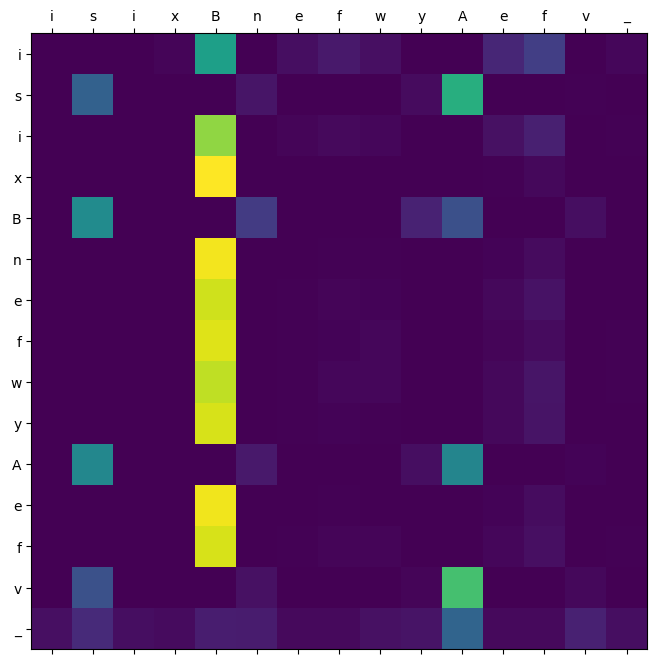

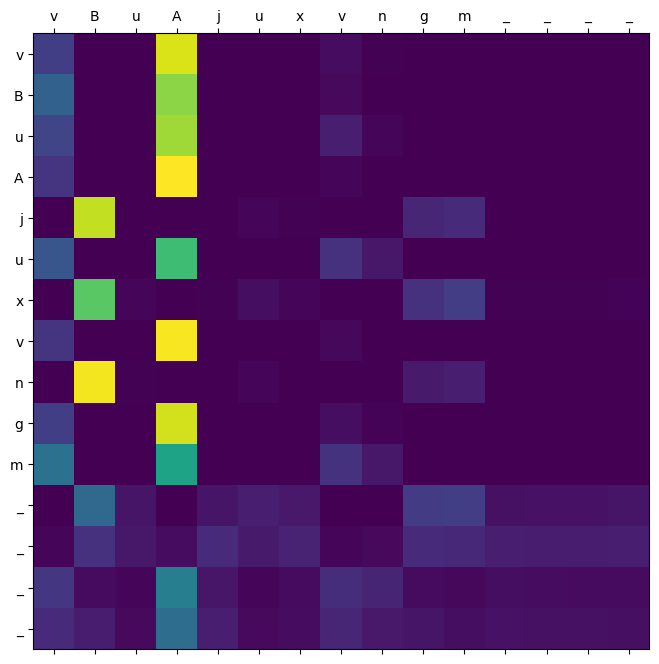

In [16]:
def plot_attn(seq, layer, head):
    slen = seqs.shape[1]
    # Access the self_attention module in the desired encoder layer and get its last_attn_scores.
    # Assuming our encoder has a ModuleList 'enc_layers'
    attn_scores = model.encoder.enc_layers[layer].self_attention.last_attn_scores.detach().cpu().numpy()
    # Expected shape (batch, num_heads, seq_len, seq_len)
    # Plot for the given sequence in the batch and desired head.
    attn_matrix = attn_scores[seq, head] if attn_scores.ndim == 4 else attn_scores[seq]
    plt.figure(figsize=(12, 8))
    ax = plt.gca()
    ax.matshow(attn_matrix)
    ax.set_xticks(np.arange(slen))
    ax.set_yticks(np.arange(slen))
    tokens = ["_ABcdefghijklmnopqrstuvwxyz"[x] for x in seqs[seq]]
    ax.set_xticklabels(tokens)
    ax.set_yticklabels(tokens)
    plt.show()

# Plot attention for sequence 0 and 3 from layer 0, head 0
for i in range(8):
    plot_attn(seq=i, layer=0, head=0)


You should see that all positions only attend to A and/or B and ignore all other positions. This makes sense, because the other positions just contain random noise. Remember that the model weights were initialized randomly. The model had no prior knowledge about the task and which positions are correlated with the labels.